In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the datasets
members = pd.read_csv('members.csv')
contributions = pd.read_csv('contributions.csv')
accounts = pd.read_csv('accounts.csv')
regions = pd.read_csv('regions.csv')

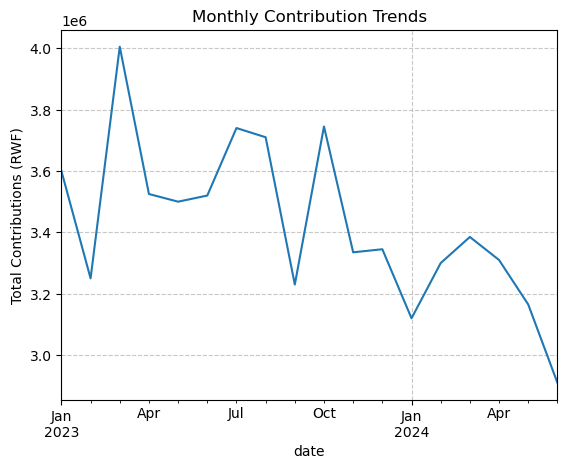

In [22]:
# 1. Plot monthly contribution trends
# Convert date to datetime
contributions['date'] = pd.to_datetime(contributions['date'])

contributions.set_index('date').resample('ME')['amount'].sum().plot(kind='line', title='Monthly Contribution Trends')
plt.ylabel('Total Contributions (RWF)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('monthly_trends.png')

In [23]:
# 2. Missing/Inconsistent values check in Members table
print(members.isnull().sum())

# Check for members with no recorded last transaction date
# This indicates accounts created but not yet funded.
missing_activity = accounts['last_transaction_date'].isnull().sum()
print(f"Accounts with zero activity: {missing_activity}")

member_id          0
age                0
gender             0
region             0
enrollment_date    0
segment            0
dtype: int64
Accounts with zero activity: 6


In [24]:
# 3. Summary table: Frequency by age group and gender
members['age_group'] = pd.cut(
    members['age'], 
    bins=[0, 25, 35, 45, 60, 100], 
    labels=['<25', '25-35', '35-45', '45-60', '60+'])

# Merge datasets for analysis
merged_df = contributions.merge(members, on='member_id')

# This ensures that all age groups (even if one has zero contributions) 
# stay visible in the final table, preventing future default changes from breaking your layout.
summary = merged_df.groupby(['age_group', 'gender'], observed=False).size().unstack()
print(summary)

gender     Female  Male
age_group              
<25           385   496
25-35         543   444
35-45         521   610
45-60         708   839
60+           166   231
